In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [137]:
# Data 
data1 = pd.read_csv("C:\\Users\\HP\\OneDrive\\Desktop\\DS\\Project\\B.Sc III Final Project\\AQI Project Data\\AQI_DATA.csv")

data1.rename(columns={'Datetime' : 'Date'},inplace= True)

data1['Date'] = pd.to_datetime(data1['Date'], errors= 'coerce')

data1.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [138]:
data2 = pd.read_csv("C:/Users/HP/OneDrive/Desktop/DS/Project/B.Sc III Final Project/AQI Project Data/AQI_DATA_2021-2025.csv")

data2['Date'] = pd.to_datetime(data2['Date'], errors= 'coerce')

data2.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Amaravati,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184,Moderate
1,Amaravati,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197,Moderate
2,Amaravati,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198,Moderate
3,Amaravati,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188,Moderate
4,Amaravati,2017-11-29,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08,173,Moderate


In [139]:
# Concat Data 
data = pd.concat([data1,data2],axis=0, ignore_index= True)
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [140]:
# Data Info
print(data.shape)
print('---------------------------------------------------------\n')
print(data.info())
print('---------------------------------------------------------\n')
print(data.describe())


(53564, 16)
---------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53564 entries, 0 to 53563
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        53564 non-null  object        
 1   Date        53564 non-null  datetime64[ns]
 2   PM2.5       53564 non-null  float64       
 3   PM10        53564 non-null  float64       
 4   NO          53564 non-null  float64       
 5   NO2         53564 non-null  float64       
 6   NOx         53564 non-null  float64       
 7   NH3         53564 non-null  float64       
 8   CO          53564 non-null  float64       
 9   SO2         53564 non-null  float64       
 10  O3          53564 non-null  float64       
 11  Benzene     53564 non-null  float64       
 12  Toluene     53564 non-null  float64       
 13  Xylene      53564 non-null  float64       
 14  AQI         53564 non-null  float64       
 15 

In [141]:
# Handle data types
data['Date'] = pd.to_datetime(data['Date'], errors= 'coerce')

print(data['Date'].dtype)

datetime64[ns]


In [142]:
# Checking Dupliacates
data.duplicated().sum()

np.int64(0)

In [143]:
# Handling Duplicate values
data.drop_duplicates(keep= 'first', inplace= True)

data.duplicated().sum()

np.int64(0)

In [144]:
# Checking Null Values
data.isna().sum().sum()

np.int64(0)

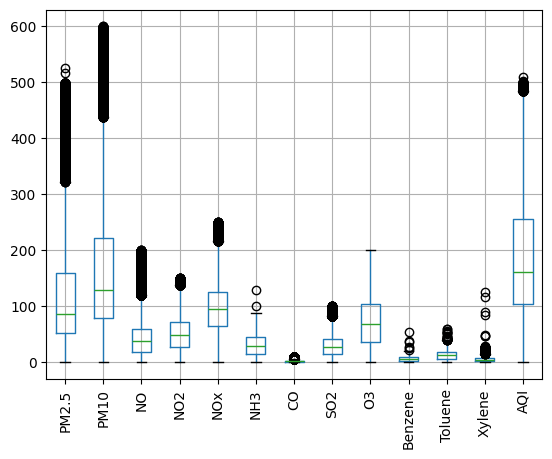

In [145]:
# checking outliers for value imputation
plt.Figure(figsize=(10,8))
data.boxplot()
plt.xticks(rotation = 90)
plt.show()

In [146]:
# Numerical and Categorical Columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

cat_cols = data.select_dtypes(include=['object']).columns

In [147]:
# Numerical cols with null values
num_cols_with_nulls = []

for col in num_cols:
    if data[col].isna().sum() > 0:
        num_cols_with_nulls.append(col)
        
print(num_cols_with_nulls)

[]


In [148]:
# Categorical cols with null values
cat_cols_with_nulls = []

for col in cat_cols:
    if data[col].isna().sum() > 0:
        cat_cols_with_nulls.append(col)
        
print(cat_cols_with_nulls)

[]


In [149]:
# Handling Null Values
data[num_cols_with_nulls] = data[num_cols_with_nulls].fillna(data[num_cols_with_nulls].median())

data['City'].fillna(data['City'].mode()[0], inplace= True)

data['Date'] = data['Date'].bfill()

C:\Users\HP\AppData\Local\Temp\ipykernel_29556\3233811489.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['City'].fillna(data['City'].mode()[0], inplace= True)


In [150]:
# Handling null values for AQI_Bucket

# Good
data.loc[
    data['AQI'].between(0, 50) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Good'

# Satisfactory
data.loc[
    data['AQI'].between(51, 100) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Satisfactory'

# Moderate
data.loc[
    data['AQI'].between(101, 200) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Moderate'

# Poor
data.loc[
    data['AQI'].between(201, 300) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Poor'

# Very Poor
data.loc[
    data['AQI'].between(301, 400) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Very Poor'

# Severe
data.loc[
    data['AQI'].between(401, 500) & data['AQI_Bucket'].isnull(),
    'AQI_Bucket'
] = 'Severe'

In [151]:
data.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [152]:
# Data Info
print(data2.shape)
print('---------------------------------------------------------\n')
print(data2.info())
print('---------------------------------------------------------\n')
print(data2.describe())

(35299, 16)
---------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35299 entries, 0 to 35298
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        35299 non-null  object        
 1   Date        35299 non-null  datetime64[ns]
 2   PM2.5       35299 non-null  float64       
 3   PM10        35299 non-null  float64       
 4   NO          35299 non-null  float64       
 5   NO2         35299 non-null  float64       
 6   NOx         35299 non-null  float64       
 7   NH3         35299 non-null  float64       
 8   CO          35299 non-null  float64       
 9   SO2         35299 non-null  float64       
 10  O3          35299 non-null  float64       
 11  Benzene     35299 non-null  float64       
 12  Toluene     35299 non-null  float64       
 13  Xylene      35299 non-null  float64       
 14  AQI         35299 non-null  int64         
 15 

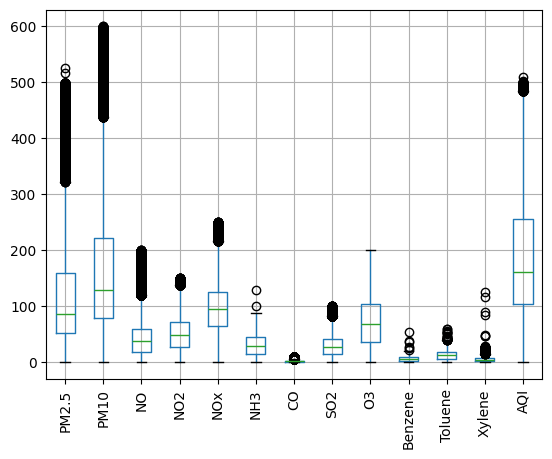

In [153]:
# checking outliers
plt.Figure(figsize=(10,8))
data.boxplot()
plt.xticks(rotation = 90)
plt.show()

In [154]:
# clip outliers for only required columns
cols = ['Benzene', 'Toluene', 'Xylene', 'AQI']

for col in cols:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)

    data[col] = data[col].clip(lower, upper)

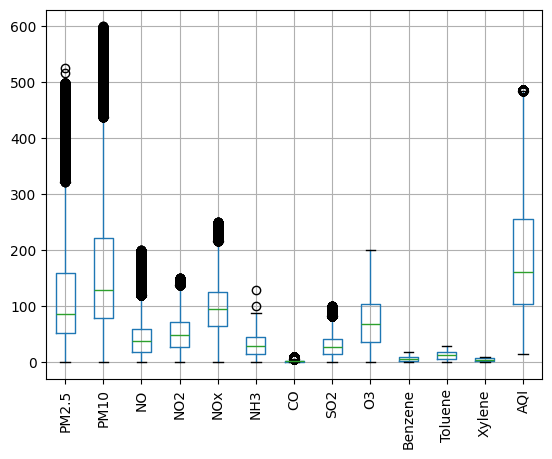

In [155]:
# cheking outliers after clipping
plt.Figure(figsize=(10,8))
data.boxplot()
plt.xticks(rotation = 90)
plt.show()

In [156]:
# Feature Engineering :- Feature Extraction
data['Day_Name'] = data['Date'].dt.day_name()

data['Month_Name'] = data['Date'].dt.month_name()

data['Year'] = data['Date'].dt.year


In [157]:
# data = data[~(data['AQI'] > 500)]   # returns boolean indexing

# # or

# data = data.query('AQI <= 500') # returns data frame

# data = data[data['AQI'] <= 500]

# print(data2.shape)

In [158]:
data.to_csv("C:\\Users\\HP\\OneDrive\\Desktop\\DS\\Project\\B.Sc III Final Project\\AQI Project Data\\AQI_FINAL_DATA.csv", index= False)

## ML Model Prediction

In [159]:
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Day_Name,Month_Name,Year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.500,Severe,Thursday,January,2015
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.900,Satisfactory,Thursday,January,2015
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,485.837,Severe,Thursday,January,2015
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.400,Very Poor,Thursday,January,2015
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,485.837,Good,Thursday,January,2015


In [160]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [161]:
# Step 1: Create encoder
ohe = OneHotEncoder(sparse_output=False)

# Step 2: Fit & transform
city_encoded = ohe.fit_transform(data[['City']])

# Step 3: Convert to DataFrame
city_df = pd.DataFrame(
    city_encoded,
    columns=ohe.get_feature_names_out(['City'])
)

# Step 4: Drop original column
data = data.drop('City', axis=1)

# Step 5: Add new columns
data = pd.concat([data, city_df], axis=1)

In [162]:
month_map = {
    'January':1,
    'February':2,
    'March':3,
    'April':4,
    'May':5,
    'June':6,
    'July':7,
    'August':8,
    'September':9,
    'October':10,
    'November':11,
    'December':12
}

day_map = {
    'Monday':1,
    'Tuesday':2,
    'Wednesday':3,
    'Thursday':4,
    'Friday':5,
    'Saturday':6,
    'Sunday':7
}


data['Month_Name'] = data['Month_Name'].map(month_map)

data['Day_Name'] = data['Day_Name'].map(day_map)


In [163]:
"""
trans_cols = ['Day_Name', 'Month_Name']

# Step 1: Create encoder
le = LabelEncoder()

# Step 2: Fit & transform
for col in trans_cols:
    data[col] = le.fit_transform(data[col])

# Show mapping
mapping = dict(
    zip(le.classes_, le.transform(le.classes_))
)

print(mapping)
"""

"\ntrans_cols = ['Day_Name', 'Month_Name']\n\n# Step 1: Create encoder\nle = LabelEncoder()\n\n# Step 2: Fit & transform\nfor col in trans_cols:\n    data[col] = le.fit_transform(data[col])\n\n# Show mapping\nmapping = dict(\n    zip(le.classes_, le.transform(le.classes_))\n)\n\nprint(mapping)\n"

In [164]:
x = data.drop(columns= ['Date', 'AQI', 'AQI_Bucket'])
y = data['AQI_Bucket']

In [165]:
x.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'Day_Name', 'Month_Name', 'Year',
       'City_Ahmedabad', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar',
       'City_Bangalore', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh',
       'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Ernakulam',
       'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur',
       'City_Jorapokhar', 'City_Kochi', 'City_Kolkata', 'City_Lucknow',
       'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam'],
      dtype='object')

In [166]:
# Train-Test-Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 18)

In [167]:
# Scaling 
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [168]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [169]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [170]:
# Model
model = RandomForestClassifier()

model.fit(x_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [171]:
# Prediction
y_hat = model.predict(x_test)

In [172]:
# Accuracy 
acc = accuracy_score(y_test, y_hat)

cr = classification_report(y_test, y_hat)

cm = confusion_matrix(y_test, y_hat)

# rmse = np.sqrt(mse)


# print("MAE :", mae)

# print("MSE :", mse)

# print("RMSE :", rmse)

print("accuracy Score :", acc)

print("classification report :\n", cr)

print("confusion matrix :\n", cm)


accuracy Score : 0.6229814244375992
classification report :
               precision    recall  f1-score   support

        Good       0.44      0.48      0.46      1071
    Moderate       0.88      0.74      0.81      3799
        Poor       0.81      0.63      0.71      2312
Satisfactory       0.76      0.58      0.66      1968
      Severe       0.17      0.56      0.27       619
   Very Poor       0.38      0.43      0.40       944

    accuracy                           0.62     10713
   macro avg       0.57      0.57      0.55     10713
weighted avg       0.72      0.62      0.66     10713

confusion matrix :
 [[ 515    1   17   79  345  114]
 [  91 2819  227  228  325  109]
 [ 142  167 1447   23  338  195]
 [ 189  203   13 1139  315  109]
 [ 105    7   10    9  348  140]
 [ 129    5   70   12  322  406]]


In [173]:
x.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'Day_Name', 'Month_Name', 'Year',
       'City_Ahmedabad', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar',
       'City_Bangalore', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh',
       'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Ernakulam',
       'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur',
       'City_Jorapokhar', 'City_Kochi', 'City_Kolkata', 'City_Lucknow',
       'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam'],
      dtype='object')

## New Data Predction

In [ ]:
# STEP 1 — CREATE NEW DATA
new_data = pd.DataFrame({

    'City': ['Delhi'],

    'PM2.5': [180],

    'PM10': [320],

    'NO': [45],

    'NO2': [60],

    'NOx': [120],

    'NH3': [35],

    'CO': [2.1],

    'SO2': [18],

    'O3': [55],

    'Benzene': [12],

    'Toluene': [20],

    'Xylene': [5],

    'Date': ['2024-01-15']

})

# STEP 2 — PROCESS DATE
new_data['Date'] = pd.to_datetime(new_data['Date'])

new_data['Year'] = new_data['Date'].dt.year

new_data['Month_Name'] = new_data['Date'].dt.month

new_data['Day_Name'] = new_data['Date'].dt.weekday

# STEP 3 — DROP DATE COLUMN
new_data.drop('Date', axis=1, inplace=True)

# STEP 4 — APPLY SAME ONEHOTENCODER

# Transform City
city_encoded = ohe.transform(new_data[['City']])

# Convert to dataframe
city_df = pd.DataFrame(
    city_encoded,
    columns=ohe.get_feature_names_out(['City'])
)

# Drop Original City Column
new_data.drop('City', axis=1, inplace=True)

# Add Encoded Columns
new_data = pd.concat(
    [new_data, city_df],
    axis=1
)

# STEP 5 — MATCH TRAINING COLUMN ORDER
new_data = new_data[x.columns]

In [ ]:
# STEP 6 — APPLY SAME SCALER
new_data_scaled = scaler.transform(new_data)

In [ ]:
# STEP 7 — PREDICT AQI
predicted_aqi = model.predict(new_data_scaled)

In [ ]:
# STEP 8 — PRINT RESULT
print("Predicted AQI :", predicted_aqi[0])

Predicted AQI : Very Poor


## Saving Models & Encoders and Scaler

In [181]:
# =========================================================
# STEP 1 : SAVE MODEL, ENCODER & SCALER
# =========================================================

import joblib

# Save trained model
joblib.dump(model, 'aqi_model.pkl')

# Save OneHotEncoder
joblib.dump(ohe, 'city_encoder.pkl')

# Save Scaler
joblib.dump(scaler, 'scaler.pkl')

# Save training columns
joblib.dump(x.columns.tolist(), 'model_columns.pkl')

print("All files saved successfully!")

All files saved successfully!
